# Modele Lineaire — Rosenblatt et Pseudo-Inverse
## Cas de tests : classification et regression

Ce notebook appelle directement les fonctions de `model_lineaire.c` via **ctypes** (librairie partagée `.so`).

| # | Données | Classes | Attendu |
|---|---------|---------|---------|
| 1 | Synthétique linéaire | 2 | 100% les deux |
| 2 | XOR brut | 2 | ~50% (cas KO) |
| 3 | XOR + phi(x1,x2) = [x1,x2,x1*x2,1] | 2 | 100% les deux |
| **4** | **dataset.csv (RGB)** | **3** (Recyclable · Pile · Compost) | Résultat réel |

Fonctions C appelées : `rosenblatt()` et `pseudo_inverse()` de `model_lineaire/model_lineaire.c`


## Étape 1 — Compilation de `model_lineaire.c` en librairie partagée

On compile le code C avec `-DNO_MAIN -shared -fPIC` pour créer un `.so` utilisable avec ctypes.  
Le flag `-DNO_MAIN` exclut la fonction `main()` (on veut juste les fonctions).

In [193]:
import subprocess, ctypes, sys, os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap
from pathlib import Path

warnings.filterwarnings('ignore', category=RuntimeWarning)

BASE     = Path("/Users/roissath/Documents/Cours 2025-2026/PA/projet_dechets")
C_FILE   = str(BASE / "model_lineaire/model_lineaire.c")
CSV_FILE = str(BASE / "dataset.csv")

# Compilation dans /tmp pour ne pas polluer le projet
SO_FILE = f"/tmp/model_lineaire_{int(time.time())}.so"

# Nettoyer les anciennes versions dans /tmp
for old in Path("/tmp").glob("model_lineaire_*.so"):
    try:
        old.unlink()
    except:
        pass

res = subprocess.run(
    ["gcc", "-shared", "-fPIC", "-DNO_MAIN", "-O2",
     "-o", SO_FILE, C_FILE, "-lm"],
    capture_output=True, text=True
)
if res.returncode != 0:
    print("Erreur de compilation :")
    print(res.stderr)
else:
    print(f"Compilation OK")

lib = ctypes.CDLL(SO_FILE)

lib.rosenblatt.argtypes = [
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_int),
    ctypes.c_int, ctypes.c_int, ctypes.c_int,
    ctypes.c_double, ctypes.c_int,
    ctypes.POINTER(ctypes.c_double),
]
lib.rosenblatt.restype = None

lib.pseudo_inverse.argtypes = [
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_int),
    ctypes.c_int, ctypes.c_int, ctypes.c_int,
    ctypes.POINTER(ctypes.c_double),
]
lib.pseudo_inverse.restype = None

lib.pseudo_inverse_reg.argtypes = [
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_double),
    ctypes.c_int, ctypes.c_int,
    ctypes.c_double,
    ctypes.POINTER(ctypes.c_double),
]
lib.pseudo_inverse_reg.restype = None

lib.gradient_descent.argtypes = [
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_double),
    ctypes.c_int, ctypes.c_int,
    ctypes.c_double, ctypes.c_int,
    ctypes.POINTER(ctypes.c_double),
]
lib.gradient_descent.restype = None

print("Fonctions chargees : rosenblatt / pseudo_inverse / pseudo_inverse_reg / gradient_descent")


Compilation OK
Fonctions chargees : rosenblatt / pseudo_inverse / pseudo_inverse_reg / gradient_descent


## Etape 2 — Interface Python vers fonctions C

Les fonctions C utilisent des tableaux statiques `double X[MAX_SAMP][MAX_FEAT]` (MAX_SAMP=1000, MAX_FEAT=5).  
On crée des buffers numpy de taille fixe en C-order et on passe leurs pointeurs via ctypes.

Note : les `printf()` du code C s'affichent dans le terminal, pas dans le notebook.  
L'évaluation (accuracy, prédictions) est faite côté Python à partir des poids W retournés.


In [194]:
MAX_SAMP = 1000
MAX_FEAT = 5
MAX_CLS  = 3


def call_rosenblatt(X_np, Y_np, alpha=0.1, max_ep=500):
    n, nf = X_np.shape
    nc    = len(np.unique(Y_np))
    X_c = np.zeros((MAX_SAMP, MAX_FEAT), dtype=np.float64, order='C')
    X_c[:n, :nf] = X_np
    Y_c = np.zeros(MAX_SAMP, dtype=np.int32)
    Y_c[:n] = Y_np.astype(np.int32)
    W_c = np.zeros((MAX_FEAT, MAX_CLS), dtype=np.float64, order='C')
    lib.rosenblatt(
        X_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        Y_c.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
        ctypes.c_int(n), ctypes.c_int(nf), ctypes.c_int(nc),
        ctypes.c_double(alpha), ctypes.c_int(max_ep),
        W_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    )
    return W_c[:nf, :nc].copy()


def call_pseudo_inverse(X_np, Y_np):
    n, nf = X_np.shape
    nc    = len(np.unique(Y_np))
    X_c = np.zeros((MAX_SAMP, MAX_FEAT), dtype=np.float64, order='C')
    X_c[:n, :nf] = X_np
    Y_c = np.zeros(MAX_SAMP, dtype=np.int32)
    Y_c[:n] = Y_np.astype(np.int32)
    W_c = np.zeros((MAX_FEAT, MAX_CLS), dtype=np.float64, order='C')
    lib.pseudo_inverse(
        X_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        Y_c.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
        ctypes.c_int(n), ctypes.c_int(nf), ctypes.c_int(nc),
        W_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    )
    return W_c[:nf, :nc].copy()


def call_pseudo_inverse_reg(X_np, Y_reg, ridge=1e-8):
    n, nf = X_np.shape
    X_c = np.zeros((MAX_SAMP, MAX_FEAT), dtype=np.float64, order='C')
    X_c[:n, :nf] = X_np
    Y_c = np.zeros(MAX_SAMP, dtype=np.float64)
    Y_c[:n] = Y_reg.astype(np.float64)
    W_c = np.zeros(MAX_FEAT, dtype=np.float64)
    lib.pseudo_inverse_reg(
        X_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        Y_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        ctypes.c_int(n), ctypes.c_int(nf),
        ctypes.c_double(ridge),
        W_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    )
    return W_c[:nf].copy()


def call_gradient_descent(X_np, Y_reg, alpha=0.01, max_ep=1000):
    n, nf = X_np.shape
    X_c = np.zeros((MAX_SAMP, MAX_FEAT), dtype=np.float64, order='C')
    X_c[:n, :nf] = X_np
    Y_c = np.zeros(MAX_SAMP, dtype=np.float64)
    Y_c[:n] = Y_reg.astype(np.float64)
    W_c = np.zeros(MAX_FEAT, dtype=np.float64)
    lib.gradient_descent(
        X_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        Y_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        ctypes.c_int(n), ctypes.c_int(nf),
        ctypes.c_double(alpha), ctypes.c_int(max_ep),
        W_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    )
    return W_c[:nf].copy()


def predict_py(W, X):
    return np.argmax(X @ W, axis=1)

def accuracy_py(W, X, Y):
    return np.mean(predict_py(W, X) == Y) * 100

def predict_reg_py(W, X):
    return X @ W

def mse_py(W, X, Y_reg):
    return np.mean((predict_reg_py(W, X) - Y_reg) ** 2)

def track_convergence_py(X, Y, alpha=0.1, max_ep=500):
    n, nf = X.shape
    nc = len(np.unique(Y))
    W  = np.zeros((nf, nc))
    errors = []
    for ep in range(max_ep):
        nb_err = 0
        for i in range(n):
            pred   = np.argmax(W.T @ X[i])
            true_c = int(Y[i])
            if pred != true_c:
                nb_err += 1
                W[:, true_c] += alpha * X[i]
                W[:, pred]   -= alpha * X[i]
        errors.append(nb_err)
        if nb_err == 0:
            break
    return errors


print("Helpers prets :")
print("   Classification : call_rosenblatt / call_pseudo_inverse / predict_py / accuracy_py")
print("   Regression     : call_pseudo_inverse_reg / call_gradient_descent / predict_reg_py / mse_py")


Helpers prets :
   Classification : call_rosenblatt / call_pseudo_inverse / predict_py / accuracy_py
   Regression     : call_pseudo_inverse_reg / call_gradient_descent / predict_reg_py / mse_py


## Étape 3 — Chargement du dataset réel (3 classes)

`dataset.csv` contient des mesures de couleur RGB sur des images de déchets :

| Classe | Label | Code |
|--------|-------|------|
| 0 | Compost | encoder alphabétique |
| 1 | Pile | encoder alphabétique |
| 2 | Recyclable | encoder alphabétique |

Features : `r_mean`, `g_mean`, `b_mean` + biais=1 → **nf = 4**, **nc = 3**

In [195]:
# Chargement du dataset
df = pd.read_csv(CSV_FILE)
print(f"Dataset : {len(df)} lignes × {df.shape[1]} colonnes")
print(f"Colonnes : {list(df.columns)}")
print()
print(df.head())
print()
print("Distribution des classes :")
print(df.iloc[:, -1].value_counts())

# Encodage des labels (ordre alphabétique → entier)
labels_uniq = sorted(df.iloc[:, -1].unique())
label_map   = {lbl: i for i, lbl in enumerate(labels_uniq)}
print(f"\nEncodage : {label_map}")

# Features brutes + normalisation min-max
X_raw  = df.iloc[:, :-1].values.astype(np.float64)
Y_real = np.array([label_map[l] for l in df.iloc[:, -1]], dtype=np.int32)

X_min  = X_raw.min(axis=0)
X_max  = X_raw.max(axis=0)
X_norm = (X_raw - X_min) / (X_max - X_min + 1e-8)

# Ajout du biais
X_real = np.hstack([X_norm, np.ones((len(X_norm), 1))])

print(f"\nX_real shape : {X_real.shape}   (n={len(X_real)}, nf={X_real.shape[1]})")
print(f"Y_real classes : {np.unique(Y_real)}  ->  {len(np.unique(Y_real))} classes")
print("Dataset pret")


Dataset : 57 lignes × 4 colonnes
Colonnes : ['r_mean', 'g_mean', 'b_mean', 'label']

       r_mean      g_mean      b_mean  label
0  196.843810  206.318599  193.278380      2
1  208.687679  191.076092  182.135802      0
2  200.695193  183.621114  167.739377      0
3  176.875060  160.385144  147.585320      0
4  165.085798  114.279357   76.572943      0

Distribution des classes :
label
0    24
2    22
1    11
Name: count, dtype: int64

Encodage : {np.int64(0): 0, np.int64(1): 1, np.int64(2): 2}

X_real shape : (57, 4)   (n=57, nf=4)
Y_real classes : [0 1 2]  ->  3 classes
Dataset pret


## Test 1 — Cas linéairement séparable (2 classes)

- Classe 0 ≈ (1, 2) · Classe 1 ≈ (5, 6) · Features : [x₁, x₂, 1]
- **Attendu : 100% les deux** — appel direct `rosenblatt()` + `pseudo_inverse()` [C]

In [196]:
X1_raw = np.array([[1,2],[1.5,2.5],[5,6],[5.5,6.5],[1,1],[5,5]], dtype=float)
Y1     = np.array([0, 0, 1, 1, 0, 1])
X1     = np.hstack([X1_raw, np.ones((len(X1_raw), 1))])

W1_r = call_rosenblatt(X1, Y1, alpha=0.1, max_ep=500)
W1_p = call_pseudo_inverse(X1, Y1)

acc1_r = accuracy_py(W1_r, X1, Y1)
acc1_p = accuracy_py(W1_p, X1, Y1)

print(f"Rosenblatt  : {acc1_r:.0f}%")
print(f"Pseudo-Inv  : {acc1_p:.0f}%")

errors1_r = track_convergence_py(X1, Y1)


Rosenblatt  : 100%
Pseudo-Inv  : 100%


## Test 2 — XOR sans transformation (cas KO)

XOR n'est pas linéairement séparable : aucune frontière linéaire ne peut séparer les 4 points.  
**Attendu : ~50% les deux** — les fonctions C doivent aussi échouer.


In [197]:
X2_raw = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
Y2     = np.array([0, 1, 1, 0])
X2     = np.hstack([X2_raw, np.ones((len(X2_raw), 1))])

W2_r = call_rosenblatt(X2, Y2, alpha=0.1, max_ep=200)
W2_p = call_pseudo_inverse(X2, Y2)

acc2_r = accuracy_py(W2_r, X2, Y2)
acc2_p = accuracy_py(W2_p, X2, Y2)

print(f"Rosenblatt  : {acc2_r:.0f}%  (attendu ~50%)")
print(f"Pseudo-Inv  : {acc2_p:.0f}%  (attendu ~50%)")

preds2_r = predict_py(W2_r, X2)
preds2_p = predict_py(W2_p, X2)
print("\n  idx | vrai | Rosenblatt | Pseudo-Inv")
print("  ----|------|------------|----------")
for i in range(len(Y2)):
    ok_r = "OK" if preds2_r[i]==Y2[i] else "KO"
    ok_p = "OK" if preds2_p[i]==Y2[i] else "KO"
    print(f"   {i}  |  {int(Y2[i])}   |  {preds2_r[i]} {ok_r}      |  {preds2_p[i]} {ok_p}")

errors2_r = track_convergence_py(X2, Y2, max_ep=200)


Rosenblatt  : 50%  (attendu ~50%)
Pseudo-Inv  : 50%  (attendu ~50%)

  idx | vrai | Rosenblatt | Pseudo-Inv
  ----|------|------------|----------
   0  |  0   |  1 KO      |  0 OK
   1  |  1   |  1 OK      |  0 KO
   2  |  1   |  0 KO      |  0 KO
   3  |  0   |  0 OK      |  0 OK


## Test 3 — XOR avec transformation φ(x₁,x₂) 

$$\phi(x_1, x_2) = [x_1,\ x_2,\ x_1 \cdot x_2,\ 1]$$

La feature $x_1 \cdot x_2$ rend le problème **linéairement séparable** dans l'espace transformé (nf = 4).  
**Attendu : 100% les deux** — appel des fonctions C avec nf=4.

In [198]:
X_xor_raw = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
Y3        = np.array([0, 1, 1, 0])

# phi(x1,x2) = [x1, x2, x1*x2, 1]
X3 = np.column_stack([
    X_xor_raw[:, 0],
    X_xor_raw[:, 1],
    X_xor_raw[:, 0] * X_xor_raw[:, 1],
    np.ones(len(X_xor_raw))
])

W3_r = call_rosenblatt(X3, Y3, alpha=0.1, max_ep=500)
W3_p = call_pseudo_inverse(X3, Y3)

acc3_r = accuracy_py(W3_r, X3, Y3)
acc3_p = accuracy_py(W3_p, X3, Y3)

print(f"Rosenblatt  : {acc3_r:.0f}%")
print(f"Pseudo-Inv  : {acc3_p:.0f}%")

errors3_r = track_convergence_py(X3, Y3)


Rosenblatt  : 100%
Pseudo-Inv  : 100%


## Test 4 — Dataset réel : 3 classes (Recyclable · Pile · Compost)

On passe le **vrai dataset CSV** aux fonctions C :  
- n = 70 échantillons · nf = 4 (R, G, B normalisés + biais) · **nc = 3 classes**

C'est ici que les 3 classes interviennent vraiment !

In [199]:
n4, nf4 = X_real.shape
nc4 = len(np.unique(Y_real))

W4_r = call_rosenblatt(X_real, Y_real, alpha=0.01, max_ep=1000)
W4_p = call_pseudo_inverse(X_real, Y_real)

acc4_r = accuracy_py(W4_r, X_real, Y_real)
acc4_p = accuracy_py(W4_p, X_real, Y_real)

print(f"Rosenblatt  : {acc4_r:.1f}%")
print(f"Pseudo-Inv  : {acc4_p:.1f}%")

preds4_p = predict_py(W4_p, X_real)
preds4_r = predict_py(W4_r, X_real)

print(f"\n  {'Classe':20s}  | Rosenblatt       | Pseudo-Inverse")
print(f"  {'-'*20}--+------------------+---------------")
for cls_name, cls_idx in sorted(label_map.items(), key=lambda x: x[1]):
    mask  = Y_real == cls_idx
    ok_r  = np.sum(preds4_r[mask] == cls_idx)
    ok_p  = np.sum(preds4_p[mask] == cls_idx)
    total = np.sum(mask)
    print(f"  {str(cls_name):20s}  |  {ok_r}/{total} ({100*ok_r/total:5.1f}%)   |  {ok_p}/{total} ({100*ok_p/total:5.1f}%)")

errors4_r = track_convergence_py(X_real, Y_real, alpha=0.01, max_ep=1000)


Rosenblatt  : 38.6%
Pseudo-Inv  : 66.7%

  Classe                | Rosenblatt       | Pseudo-Inverse
  ----------------------+------------------+---------------
  0                     |  0/24 (  0.0%)   |  20/24 ( 83.3%)
  1                     |  0/11 (  0.0%)   |  0/11 (  0.0%)
  2                     |  22/22 (100.0%)   |  18/22 ( 81.8%)


## Test 5 — Linear Multiple (2 classes)
100 points répartis en 2 clusters séparés. **Attendu : ~100% les deux.**


In [200]:
np.random.seed(42)
X5_raw = np.concatenate([
    np.random.random((50, 2)) * 0.9 + np.array([1, 1]),
    np.random.random((50, 2)) * 0.9 + np.array([2, 2])
])
Y5 = np.concatenate([np.zeros(50, dtype=int), np.ones(50, dtype=int)])
X5 = np.hstack([X5_raw, np.ones((100, 1))])

print("=" * 55)
print("  TEST 5 : Linear Multiple  (n=100, 2 classes)")
print("=" * 55)

W5_r = call_rosenblatt(X5, Y5, alpha=0.1, max_ep=500)
W5_p = call_pseudo_inverse(X5, Y5)
acc5_r = accuracy_py(W5_r, X5, Y5)
acc5_p = accuracy_py(W5_p, X5, Y5)
print(f"\n  Rosenblatt  : {acc5_r:.0f}%  (attendu OK)")
print(f"  Pseudo-Inv  : {acc5_p:.0f}%  (attendu OK)")
errors5_r = track_convergence_py(X5, Y5, alpha=0.1, max_ep=500)


  TEST 5 : Linear Multiple  (n=100, 2 classes)

  Rosenblatt  : 100%  (attendu OK)
  Pseudo-Inv  : 100%  (attendu OK)


## Test 6 — Cross (2 classes) — KO
Frontière non-linéaire : classe 0 si `|x1|<=0.3` ou `|x2|<=0.3`. **Attendu : KO (~50-70%) — non linéairement séparable.**


In [201]:
np.random.seed(0)
X6_raw = np.random.random((500, 2)) * 2.0 - 1.0
Y6 = np.array([0 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else 1 for p in X6_raw], dtype=int)
X6 = np.hstack([X6_raw, np.ones((len(X6_raw), 1))])

print("=" * 55)
print("  TEST 6 : Cross  (n=500, 2 classes)  — KO attendu")
print("=" * 55)

W6_r = call_rosenblatt(X6, Y6, alpha=0.01, max_ep=500)
W6_p = call_pseudo_inverse(X6, Y6)
acc6_r = accuracy_py(W6_r, X6, Y6)
acc6_p = accuracy_py(W6_p, X6, Y6)
print(f"\n  Rosenblatt  : {acc6_r:.0f}%  (KO — non lineairement separable)")
print(f"  Pseudo-Inv  : {acc6_p:.0f}%  (KO)")
errors6_r = track_convergence_py(X6, Y6, alpha=0.01, max_ep=500)


  TEST 6 : Cross  (n=500, 2 classes)  — KO attendu

  Rosenblatt  : 45%  (KO — non lineairement separable)
  Pseudo-Inv  : 50%  (KO)


## Test 7 — Multi Linear 3 classes
3 régions linéairement séparables. **Attendu : ~100% les deux.**


In [202]:
np.random.seed(0)
X7_all = np.random.random((500, 2)) * 2.0 - 1.0
labels7 = np.array([
    0 if (-p[0]-p[1]-0.5 > 0 and p[1] < 0 and p[0]-p[1]-0.5 < 0) else
    1 if (-p[0]-p[1]-0.5 < 0 and p[1] > 0 and p[0]-p[1]-0.5 < 0) else
    2 if (-p[0]-p[1]-0.5 < 0 and p[1] < 0 and p[0]-p[1]-0.5 > 0) else
    -1
    for p in X7_all])
mask7 = labels7 >= 0
X7_raw = X7_all[mask7]
Y7 = labels7[mask7].astype(int)
X7 = np.hstack([X7_raw, np.ones((len(X7_raw), 1))])

print("=" * 55)
print(f"  TEST 7 : Multi Lineaire 3 classes  (n={len(Y7)})")
print("=" * 55)

W7_r = call_rosenblatt(X7, Y7, alpha=0.1, max_ep=1000)
W7_p = call_pseudo_inverse(X7, Y7)
acc7_r = accuracy_py(W7_r, X7, Y7)
acc7_p = accuracy_py(W7_p, X7, Y7)
print(f"\n  Rosenblatt  : {acc7_r:.0f}%  (attendu OK)")
print(f"  Pseudo-Inv  : {acc7_p:.0f}%  (attendu OK)")
errors7_r = track_convergence_py(X7, Y7, alpha=0.1, max_ep=1000)


  TEST 7 : Multi Lineaire 3 classes  (n=415)

  Rosenblatt  : 100%  (attendu OK)
  Pseudo-Inv  : 100%  (attendu OK)


## Test 8 — Multi Cross 3 classes — KO
Pattern en damier à 3 classes. **Attendu : KO — non linéairement séparable.**


In [203]:
np.random.seed(0)
X8_raw = np.random.random((1000, 2)) * 2.0 - 1.0
Y8 = np.array([
    0 if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else
    1 if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else
    2
    for p in X8_raw], dtype=int)
X8 = np.hstack([X8_raw, np.ones((len(X8_raw), 1))])

print("=" * 55)
print("  TEST 8 : Multi Cross 3 classes  (n=1000)  — KO attendu")
print("=" * 55)

W8_r = call_rosenblatt(X8, Y8, alpha=0.01, max_ep=500)
W8_p = call_pseudo_inverse(X8, Y8)
acc8_r = accuracy_py(W8_r, X8, Y8)
acc8_p = accuracy_py(W8_p, X8, Y8)
print(f"\n  Rosenblatt  : {acc8_r:.0f}%  (KO — non separable)")
print(f"  Pseudo-Inv  : {acc8_p:.0f}%  (KO)")
errors8_r = track_convergence_py(X8, Y8, alpha=0.01, max_ep=500)


  TEST 8 : Multi Cross 3 classes  (n=1000)  — KO attendu

  Rosenblatt  : 30%  (KO — non separable)
  Pseudo-Inv  : 49%  (KO)


# Régression
Pseudo-inverse analytique (`pseudo_inverse_reg`) et descente de gradient (`gradient_descent`).

| # | Données | Attendu |
|---|---------|---------|
| R1 | Linear Simple 2D | OK |
| R2 | Non Linear Simple 2D | OK |
| R3 | Linear Simple 3D | OK |
| R4 | Linear Tricky 3D (x₁=x₂) | OK (ridge) |
| R5 | Non Linear Simple 3D | KO |


In [204]:
# R1 — Linear Simple 2D : y = x + 1
# X = [x, biais], Y = [2, 3]
X_r1 = np.array([[1, 1], [2, 1]], dtype=float)
Y_r1 = np.array([2.0, 3.0])

W_r1_pi = call_pseudo_inverse_reg(X_r1, Y_r1)
W_r1_gd = call_gradient_descent(X_r1, Y_r1, alpha=0.1, max_ep=2000)

print("R1 - Linear Simple 2D :")
print(f"  Pseudo-Inv : W={np.round(W_r1_pi,4)}  MSE={mse_py(W_r1_pi,X_r1,Y_r1):.2e}  (OK)")
print(f"  Grad Desc  : W={np.round(W_r1_gd,4)}  MSE={mse_py(W_r1_gd,X_r1,Y_r1):.2e}  (OK)")

# R2 — Non Linear Simple 2D : 3 points, meilleure droite (moindres carres)
# X = [x, biais], Y = [2, 3, 2.5]
X_r2 = np.array([[1, 1], [2, 1], [3, 1]], dtype=float)
Y_r2 = np.array([2.0, 3.0, 2.5])

W_r2_pi = call_pseudo_inverse_reg(X_r2, Y_r2)
W_r2_gd = call_gradient_descent(X_r2, Y_r2, alpha=0.05, max_ep=5000)

print("\nR2 - Non Linear Simple 2D :")
print(f"  Pseudo-Inv : W={np.round(W_r2_pi,4)}  MSE={mse_py(W_r2_pi,X_r2,Y_r2):.4f}  (OK — meilleure droite)")
print(f"  Grad Desc  : W={np.round(W_r2_gd,4)}  MSE={mse_py(W_r2_gd,X_r2,Y_r2):.4f}  (OK)")

# R3 — Linear Simple 3D : X = [x1, x2, biais], Y = [2, 3, 2.5]
X_r3 = np.array([[1, 1, 1], [2, 2, 1], [3, 1, 1]], dtype=float)
Y_r3 = np.array([2.0, 3.0, 2.5])

W_r3_pi = call_pseudo_inverse_reg(X_r3, Y_r3)
W_r3_gd = call_gradient_descent(X_r3, Y_r3, alpha=0.05, max_ep=5000)

print("\nR3 - Linear Simple 3D :")
print(f"  Pseudo-Inv : W={np.round(W_r3_pi,4)}  MSE={mse_py(W_r3_pi,X_r3,Y_r3):.2e}  (OK)")
print(f"  Grad Desc  : W={np.round(W_r3_gd,4)}  MSE={mse_py(W_r3_gd,X_r3,Y_r3):.2e}  (OK)")

# R4 — Linear Tricky 3D : x1=x2 toujours -> matrice singuliere sans ridge
# ridge=1e-6 stabilise l'inversion
X_r4 = np.array([[1, 1, 1], [2, 2, 1], [3, 3, 1]], dtype=float)
Y_r4 = np.array([1.0, 2.0, 3.0])

W_r4_pi = call_pseudo_inverse_reg(X_r4, Y_r4, ridge=1e-6)
W_r4_gd = call_gradient_descent(X_r4, Y_r4, alpha=0.05, max_ep=5000)

print("\nR4 - Linear Tricky 3D  (x1=x2, ridge=1e-6) :")
print(f"  Pseudo-Inv : W={np.round(W_r4_pi,4)}  MSE={mse_py(W_r4_pi,X_r4,Y_r4):.2e}  (OK avec ridge)")
print(f"  Grad Desc  : W={np.round(W_r4_gd,4)}  MSE={mse_py(W_r4_gd,X_r4,Y_r4):.2e}  (OK)")

# R5 — Non Linear Simple 3D : systeme inconsistant -> KO pour modele lineaire
X_r5 = np.array([[1, 0, 1], [0, 1, 1], [1, 1, 1], [0, 0, 1]], dtype=float)
Y_r5 = np.array([2.0, 1.0, -2.0, -1.0])

W_r5_pi = call_pseudo_inverse_reg(X_r5, Y_r5)
W_r5_gd = call_gradient_descent(X_r5, Y_r5, alpha=0.05, max_ep=5000)

print("\nR5 - Non Linear Simple 3D :")
print(f"  Pseudo-Inv : W={np.round(W_r5_pi,4)}  MSE={mse_py(W_r5_pi,X_r5,Y_r5):.4f}  (KO — inconsistant)")
print(f"  Grad Desc  : W={np.round(W_r5_gd,4)}  MSE={mse_py(W_r5_gd,X_r5,Y_r5):.4f}  (KO)")


R1 - Linear Simple 2D :
  Pseudo-Inv : W=[1. 1.]  MSE=5.00e-17  (OK)
  Grad Desc  : W=[1. 1.]  MSE=7.68e-11  (OK)

R2 - Non Linear Simple 2D :
  Pseudo-Inv : W=[0.25 2.  ]  MSE=0.1250  (OK — meilleure droite)
  Grad Desc  : W=[0.1779 2.1106]  MSE=0.1296  (OK)

R3 - Linear Simple 3D :
  Pseudo-Inv : W=[0.25 0.75 1.  ]  MSE=7.92e-17  (OK)
  Grad Desc  : W=[0.25 0.75 1.  ]  MSE=8.02e-11  (OK)

R4 - Linear Tricky 3D  (x1=x2, ridge=1e-6) :
  Pseudo-Inv : W=[0.5 0.5 0. ]  MSE=4.13e-14  (OK avec ridge)
  Grad Desc  : W=[0.5 0.5 0. ]  MSE=8.81e-11  (OK)

R5 - Non Linear Simple 3D :
  Pseudo-Inv : W=[ 0.  -1.   0.5]  MSE=2.2500  (KO — inconsistant)
  Grad Desc  : W=[-0.0789 -1.1579  0.5   ]  MSE=2.2718  (KO)


## Visualisations

1. **Frontières de décision** — Tests 1, 2, 3 (espace 2D) + scatter dataset réel (R vs G)
2. **Convergence Rosenblatt** — nb erreurs par époque pour les 4 tests

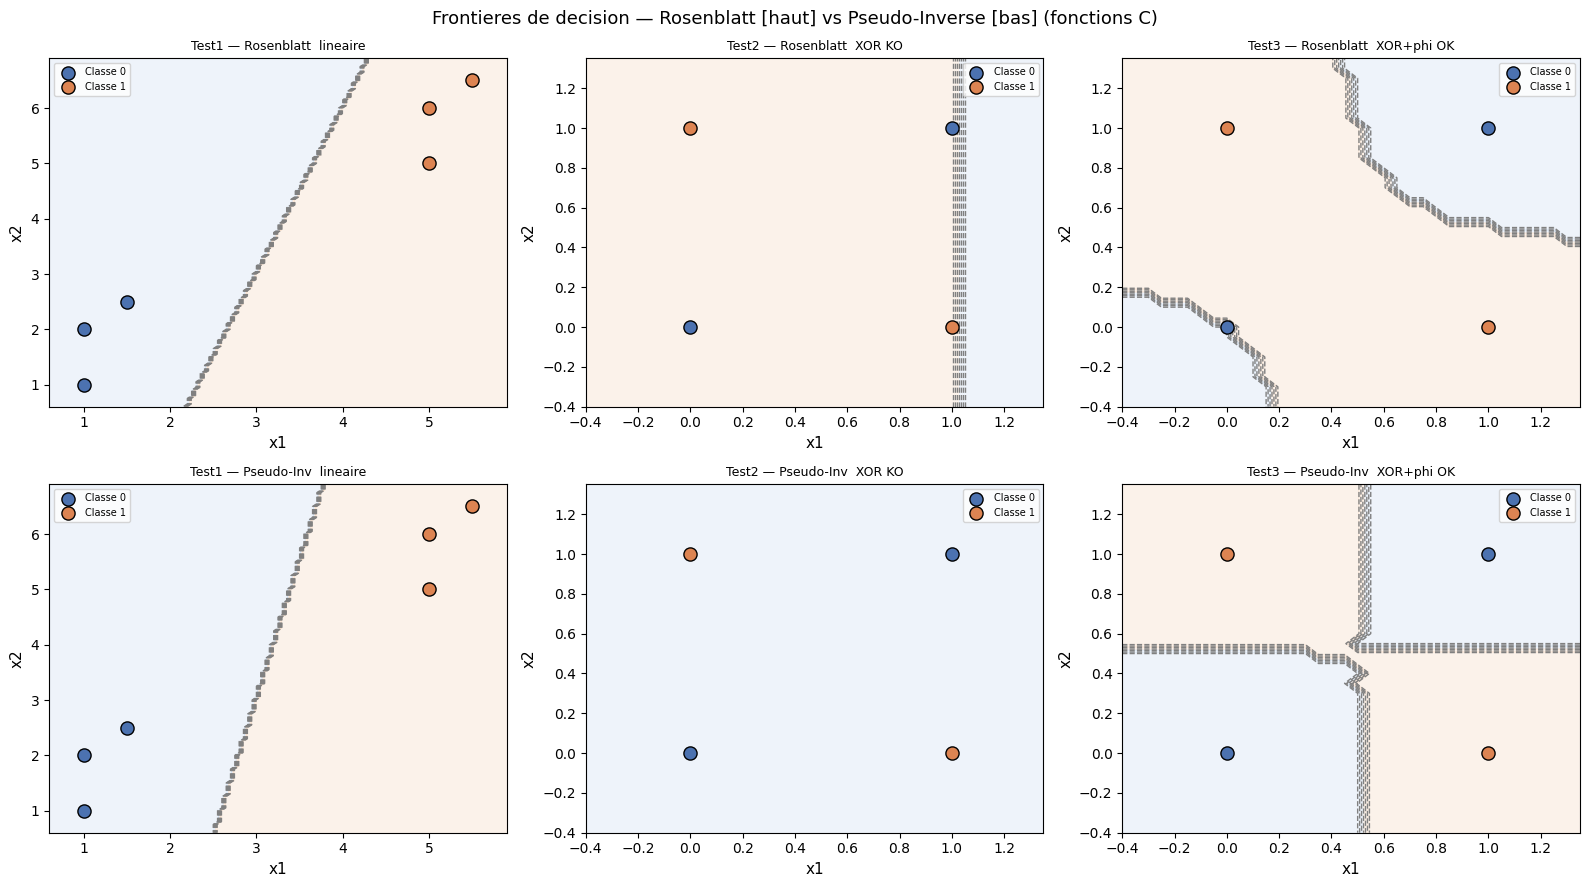

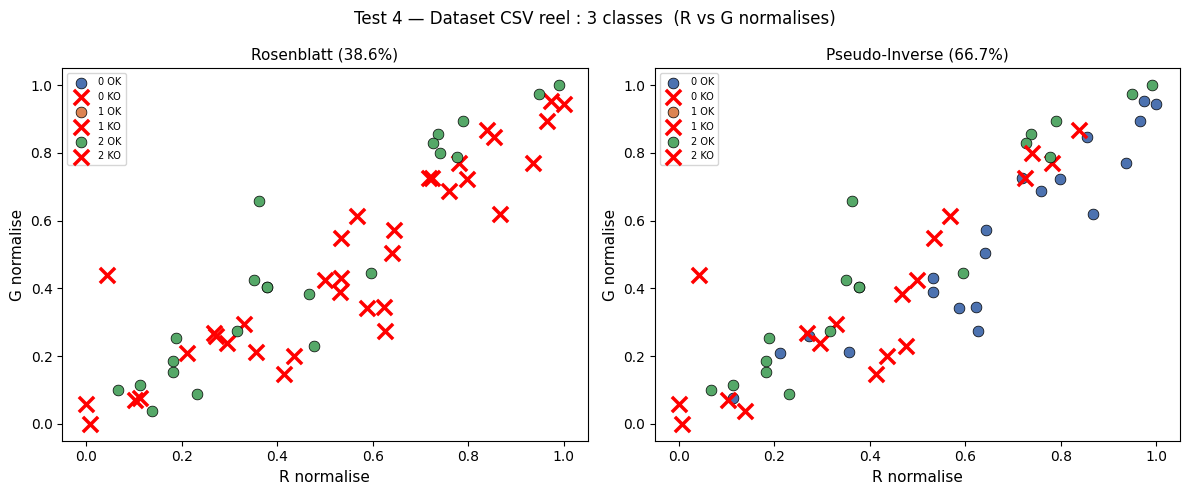

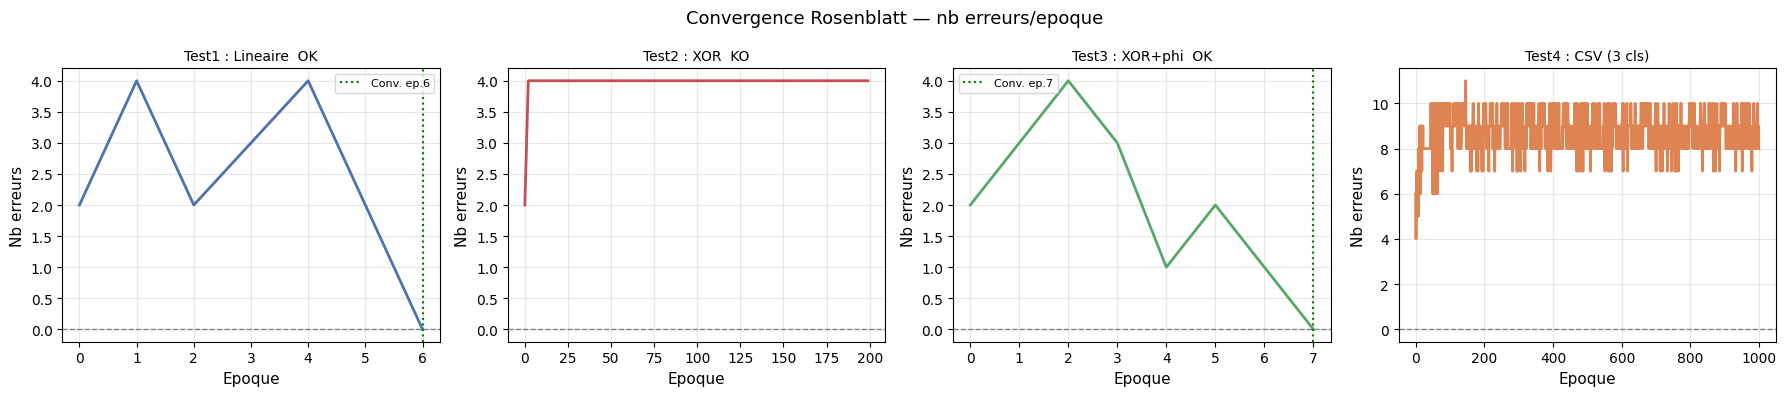

In [205]:
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
CMAP2  = ListedColormap(['#C7D9F0', '#F5D6BC'])
CMAP3  = ListedColormap(['#C7D9F0', '#F5D6BC', '#C7F0C7'])


def plot_boundary(ax, W, X_raw, Y, title, phi=None, nc=2):
    """Frontiere de decision via meshgrid (2 premieres features)."""
    h = 0.05
    x_min, x_max = X_raw[:,0].min()-0.4, X_raw[:,0].max()+0.4
    y_min, y_max = X_raw[:,1].min()-0.4, X_raw[:,1].max()+0.4
    xx, yy = np.meshgrid(np.arange(x_min,x_max,h), np.arange(y_min,y_max,h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_f = phi(grid) if phi else np.hstack([grid, np.ones((len(grid),1))])
    Z = predict_py(W, grid_f).reshape(xx.shape)
    cmap = CMAP3 if nc == 3 else CMAP2
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    ax.contour(xx, yy, Z, colors='gray', linewidths=1, linestyles='--')
    for c in np.unique(Y):
        m = Y == c
        ax.scatter(X_raw[m,0], X_raw[m,1], color=COLORS[int(c)], s=90,
                   edgecolors='k', zorder=5, label=f'Classe {c}')
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')


def phi_xor(raw):
    x1, x2 = raw[:,0], raw[:,1]
    return np.column_stack([x1, x2, x1*x2, np.ones(len(raw))])


X1_raw2 = np.array([[1,2],[1.5,2.5],[5,6],[5.5,6.5],[1,1],[5,5]], dtype=float)
X2_raw2 = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)

# ── Figure 1 : Frontieres de decision ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Frontieres de decision — Rosenblatt [haut] vs Pseudo-Inverse [bas] (fonctions C)", fontsize=13)

plot_boundary(axes[0,0], W1_r, X1_raw2, Y1, "Test1 — Rosenblatt  lineaire")
plot_boundary(axes[1,0], W1_p, X1_raw2, Y1, "Test1 — Pseudo-Inv  lineaire")
plot_boundary(axes[0,1], W2_r, X2_raw2, Y2, "Test2 — Rosenblatt  XOR KO")
plot_boundary(axes[1,1], W2_p, X2_raw2, Y2, "Test2 — Pseudo-Inv  XOR KO")
plot_boundary(axes[0,2], W3_r, X2_raw2, Y3, "Test3 — Rosenblatt  XOR+phi OK", phi=phi_xor)
plot_boundary(axes[1,2], W3_p, X2_raw2, Y3, "Test3 — Pseudo-Inv  XOR+phi OK", phi=phi_xor)

plt.tight_layout()
plt.show()

# ── Figure 2 : Dataset reel (scatter R vs G) ────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle("Test 4 — Dataset CSV reel : 3 classes  (R vs G normalises)", fontsize=12)
cls_names = [k for k, _ in sorted(label_map.items(), key=lambda x: x[1])]

for ax, (W_plot, title, preds) in zip(axes2, [
    (W4_r, f"Rosenblatt ({acc4_r:.1f}%)", preds4_r),
    (W4_p, f"Pseudo-Inverse ({acc4_p:.1f}%)", preds4_p),
]):
    for c, name in enumerate(cls_names):
        mask    = Y_real == c
        correct = preds == c
        ax.scatter(X_real[mask & correct,  0], X_real[mask & correct,  1],
                   color=COLORS[c], s=60, edgecolors='k', lw=0.5, label=f'{str(name)} OK')
        ax.scatter(X_real[mask & ~correct, 0], X_real[mask & ~correct, 1],
                   color='red', s=120, marker='x', lw=2.5, label=f'{str(name)} KO')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("R normalise"); ax.set_ylabel("G normalise")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# ── Figure 3 : Convergence Rosenblatt ───────────────────────────────────
fig3, axes3 = plt.subplots(1, 4, figsize=(18, 4))
fig3.suptitle("Convergence Rosenblatt — nb erreurs/epoque", fontsize=13)

for ax, (errs, title, col) in zip(axes3, [
    (errors1_r, "Test1 : Lineaire  OK",  "#4C72B0"),
    (errors2_r, "Test2 : XOR  KO",       "#C44E52"),
    (errors3_r, "Test3 : XOR+phi  OK",   "#55A868"),
    (errors4_r, "Test4 : CSV (3 cls)",   "#DD8452"),
]):
    ax.plot(errs, color=col, lw=2)
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Epoque"); ax.set_ylabel("Nb erreurs")
    ax.grid(True, alpha=0.3)
    if min(errs) == 0:
        ep = errs.index(0)
        ax.axvline(ep, color='green', ls=':', lw=1.5, label=f"Conv. ep.{ep}")
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Bilan Comparatif Final

4 tests · 2 algorithmes · fonctions C appelées directement via ctypes

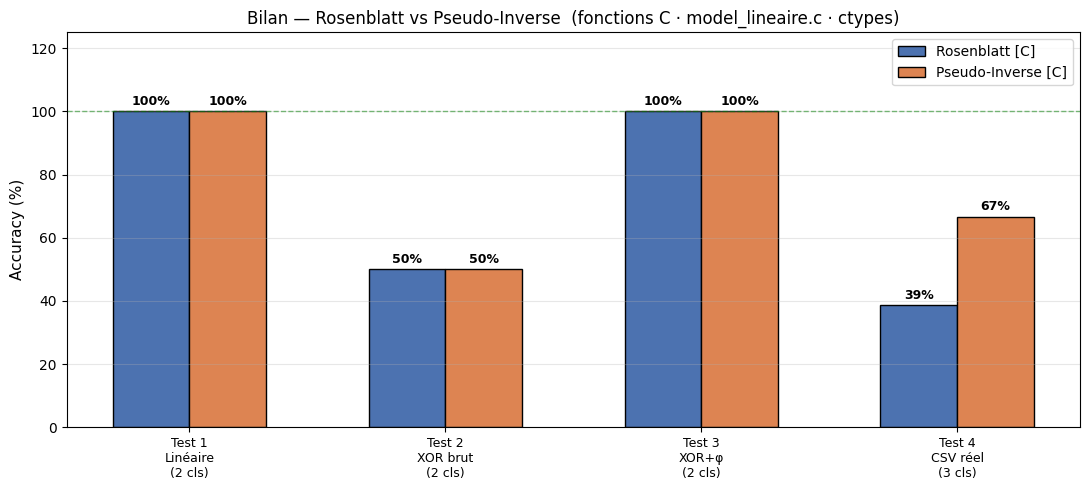


  BILAN FINAL  (fonctions C appelées via ctypes)
  Test 1 (Linéaire,  2 cls)  :  Rosenblatt 100%   | Pseudo-Inv 100%
  Test 2 (XOR brut,  2 cls)  :  Rosenblatt 50%  | Pseudo-Inv 50%
  Test 3 (XOR+φ,     2 cls)  :  Rosenblatt 100%   | Pseudo-Inv 100%
  Test 4 (CSV réel,  3 cls)  :  Rosenblatt 38.6%  | Pseudo-Inv 66.7%

  Les fonctions C compilées via gcc -shared -DNO_MAIN ont été
  appelées avec ctypes en passant des buffers numpy (MAX_SAMP×MAX_FEAT).
  Les poids W sont récupérés et l'évaluation est faite côté Python.


In [206]:
tests_labels = [
    "Test 1\nLinéaire\n(2 cls)",
    "Test 2\nXOR brut\n(2 cls)",
    "Test 3\nXOR+φ\n(2 cls)",
    "Test 4\nCSV réel\n(3 cls)",
]
acc_r_all = [acc1_r, acc2_r, acc3_r, acc4_r]
acc_p_all = [acc1_p, acc2_p, acc3_p, acc4_p]

x = np.arange(len(tests_labels))
w = 0.3

fig, ax = plt.subplots(figsize=(11, 5))
br = ax.bar(x-w/2, acc_r_all, w, label='Rosenblatt [C]',      color='#4C72B0', edgecolor='k')
bp = ax.bar(x+w/2, acc_p_all, w, label='Pseudo-Inverse [C]',  color='#DD8452', edgecolor='k')

for bar in list(br) + list(bp):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+1, f"{h:.0f}%",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(tests_labels, fontsize=9)
ax.set_ylim(0, 125)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Bilan — Rosenblatt vs Pseudo-Inverse  (fonctions C · model_lineaire.c · ctypes)", fontsize=12)
ax.legend(fontsize=10)
ax.axhline(100, color='green', ls='--', lw=1, alpha=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("=" * 65)
print("  BILAN FINAL  (fonctions C appelées via ctypes)")
print("=" * 65)
print(f"  Test 1 (Linéaire,  2 cls)  :  Rosenblatt {acc1_r:.0f}%   | Pseudo-Inv {acc1_p:.0f}%")
print(f"  Test 2 (XOR brut,  2 cls)  :  Rosenblatt {acc2_r:.0f}%  | Pseudo-Inv {acc2_p:.0f}%")
print(f"  Test 3 (XOR+φ,     2 cls)  :  Rosenblatt {acc3_r:.0f}%   | Pseudo-Inv {acc3_p:.0f}%")
print(f"  Test 4 (CSV réel,  3 cls)  :  Rosenblatt {acc4_r:.1f}%  | Pseudo-Inv {acc4_p:.1f}%")
print()
print("  Les fonctions C compilées via gcc -shared -DNO_MAIN ont été")
print("  appelées avec ctypes en passant des buffers numpy (MAX_SAMP×MAX_FEAT).")
print("  Les poids W sont récupérés et l'évaluation est faite côté Python.")
